## Google Play Store App Analysis and User Sentiment Analysis
## Objective
To analyze Google Play Store applications, identify app trends,
study ratings, installs and pricing, and analyze user sentiment
to generate useful business insights.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
apps = pd.read_csv("google_play_store_dataset.csv")
reviews = pd.read_csv("17-googleplaystore_user_reviews.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [5]:
apps.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [7]:
print("Apps Dataset Shape:", apps.shape)
print("Reviews Dataset Shape:", reviews.shape)

Apps Dataset Shape: (10841, 13)
Reviews Dataset Shape: (64295, 5)


In [8]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [9]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [10]:
print("Missing values in Apps Dataset:")
print(apps.isnull().sum())

Missing values in Apps Dataset:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [11]:
print("Missing values in Reviews Dataset:")
print(reviews.isnull().sum())

Missing values in Reviews Dataset:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [12]:
print("Duplicate rows in Apps Dataset:", apps.duplicated().sum())
print("Duplicate rows in Reviews Dataset:", reviews.duplicated().sum())

Duplicate rows in Apps Dataset: 483
Duplicate rows in Reviews Dataset: 33616


In [13]:
apps.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [14]:
apps['Rating'] = pd.to_numeric(apps['Rating'], errors='coerce')

In [15]:
apps['Rating'].dtype

dtype('float64')

In [16]:
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

In [17]:
apps['Reviews'].dtype

dtype('float64')

In [18]:
apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)

apps['Installs'] = pd.to_numeric(
    apps['Installs'],
    errors='coerce'
)

In [19]:
apps['Installs'].head()

0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64

In [20]:
apps['Price'] = apps['Price'].str.replace('$', '', regex=False)

apps['Price'] = pd.to_numeric(
    apps['Price'],
    errors='coerce'
)

In [21]:
apps['Price'].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

In [22]:
apps['Size'] = apps['Size'].replace(
    'Varies with device',
    np.nan
)

apps['Size'] = apps['Size'].str.replace(
    'M',
    '',
    regex=False
)

apps['Size'] = apps['Size'].str.replace(
    'k',
    '',
    regex=False
)

apps['Size'] = pd.to_numeric(
    apps['Size'],
    errors='coerce'
)

In [23]:
apps['Size'].head()

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64

In [24]:
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              1
Size              1696
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [25]:
apps['Rating'] = apps['Rating'].fillna(
    apps['Rating'].median()
)

In [26]:
apps['Size'] = apps['Size'].fillna(
    apps['Size'].median()
)

In [27]:
apps.isnull().sum()

App               0
Category          0
Rating            0
Reviews           1
Size              0
Installs          1
Type              1
Price             1
Content Rating    1
Genres            0
Last Updated      0
Current Ver       8
Android Ver       3
dtype: int64

In [28]:
apps['App'].duplicated().sum()

np.int64(1181)

In [29]:
apps = apps.drop_duplicates(
    subset='App',
    keep='first'
)

In [30]:
apps.shape

(9660, 13)

In [31]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [32]:
reviews = reviews.dropna(
    subset=['Translated_Review']
)

In [33]:
reviews = reviews.dropna(
    subset=['Translated_Review']
)

In [34]:
reviews = reviews.drop_duplicates()

In [35]:
reviews.shape

(29692, 5)

In [36]:
print("Apps Dataset:")
apps.info()

print("\nReviews Dataset:")
reviews.info()

Apps Dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 9660 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9660 non-null   object 
 1   Category        9660 non-null   object 
 2   Rating          9660 non-null   float64
 3   Reviews         9659 non-null   float64
 4   Size            9660 non-null   float64
 5   Installs        9659 non-null   float64
 6   Type            9659 non-null   object 
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   object 
 9   Genres          9660 non-null   object 
 10  Last Updated    9660 non-null   object 
 11  Current Ver     9652 non-null   object 
 12  Android Ver     9657 non-null   object 
dtypes: float64(5), object(8)
memory usage: 1.0+ MB

Reviews Dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 29692 entries, 0 to 64230
Data columns (total 5 columns):
 #   Column                  Non-Nu

In [37]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Data Cleaning Summary

The datasets were cleaned by handling missing values,
removing duplicate records, and correcting data types.
The Installs and Price columns were converted into numeric
values, while the Size column was standardized for analysis.
The cleaned datasets are now ready for exploratory data analysis.

## Category Analysis

This section analyzes the distribution of applications across
different Google Play Store categories.

In [38]:
category_count = apps['Category'].value_counts()

category_count

Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           163
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
ART_AND_DESIGN           64
EVENTS                   64
PARENTING                60
COMICS                   56
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

In [39]:
top_categories = category_count.head(10)

top_categories

Category
FAMILY             1832
GAME                959
TOOLS               827
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64

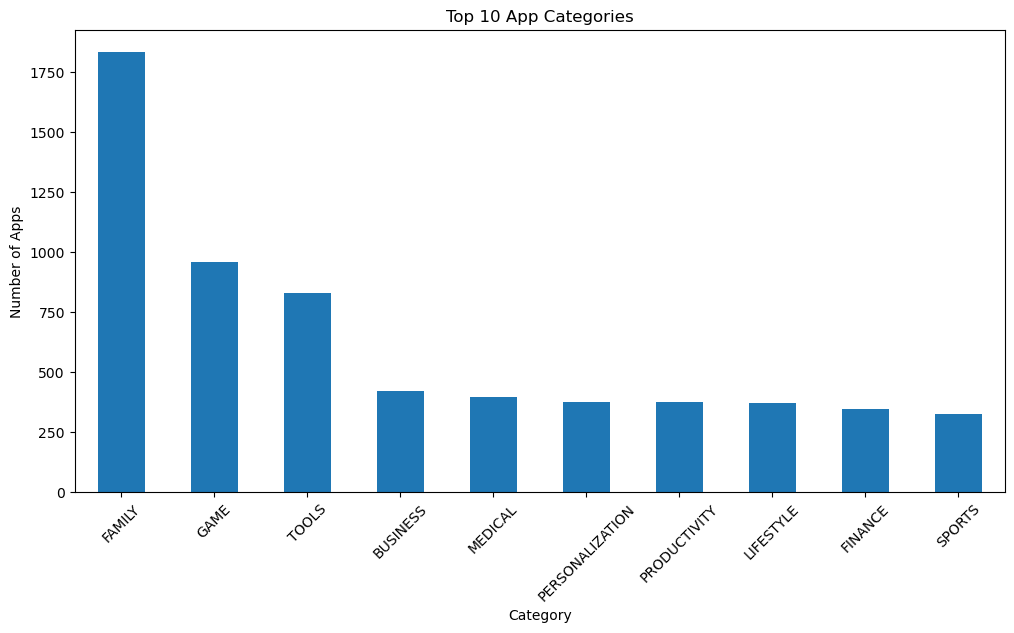

In [40]:
plt.figure(figsize=(12, 6))

top_categories.plot(kind='bar')

plt.title('Top 10 App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)

plt.show()

In [41]:
most_saturated = category_count.idxmax()
highest_count = category_count.max()

print("Most saturated category:", most_saturated)
print("Number of apps:", highest_count)

Most saturated category: FAMILY
Number of apps: 1832


### Observation

The category with the highest number of applications is the
most saturated category in the Google Play Store dataset.
The distribution shows which categories have a larger number
of competing applications.

## Rating Analysis

This section analyzes the distribution of application ratings
and compares average ratings across different categories.

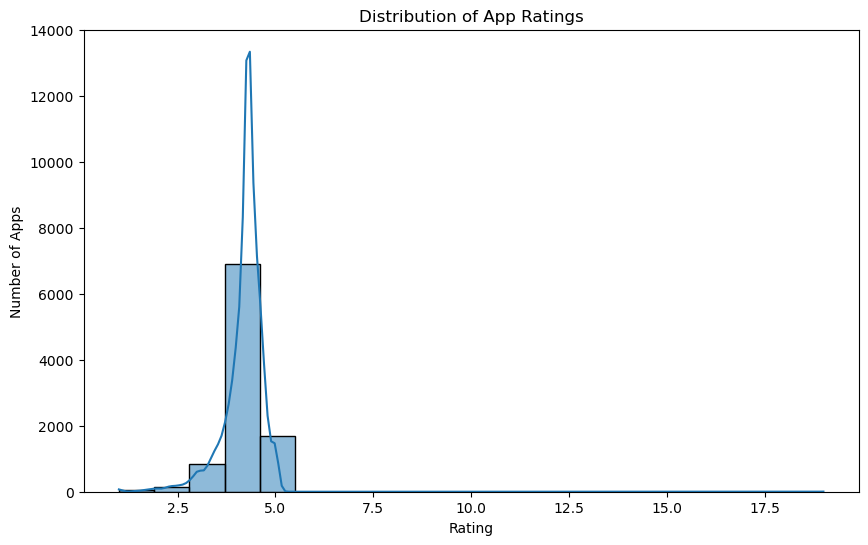

In [43]:
plt.figure(figsize=(10, 6))

sns.histplot(
    apps['Rating'],
    bins=20,
    kde=True
)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.show()

In [44]:
average_rating = (
    apps.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

average_rating

Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.363866
ART_AND_DESIGN          4.354687
BOOKS_AND_REFERENCE     4.334234
PERSONALIZATION         4.325532
PARENTING               4.300000
BEAUTY                  4.283019
SOCIAL                  4.255230
HEALTH_AND_FITNESS      4.251736
GAME                    4.249948
WEATHER                 4.248101
SHOPPING                4.237624
SPORTS                  4.232923
LIBRARIES_AND_DEMO      4.207143
PRODUCTIVITY            4.206150
AUTO_AND_VEHICLES       4.205882
MEDICAL                 4.202025
FAMILY                  4.194378
FOOD_AND_DRINK          4.192857
COMICS                  4.185714
HOUSE_AND_HOME          4.174324
BUSINESS                4.173810
PHOTOGRAPHY             4.166548
NEWS_AND_MAGAZINES      4.156693
COMMUNICATION           4.154921
FINANCE                 4.138551
ENTERTAINMENT           4.135294
LIFESTYLE               4.131436
TRAVEL_AND_LOCAL        4.103196
T

In [45]:
top_rated_categories = average_rating.head(10)

top_rated_categories

Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.363866
ART_AND_DESIGN          4.354687
BOOKS_AND_REFERENCE     4.334234
PERSONALIZATION         4.325532
PARENTING               4.300000
BEAUTY                  4.283019
SOCIAL                  4.255230
HEALTH_AND_FITNESS      4.251736
Name: Rating, dtype: float64

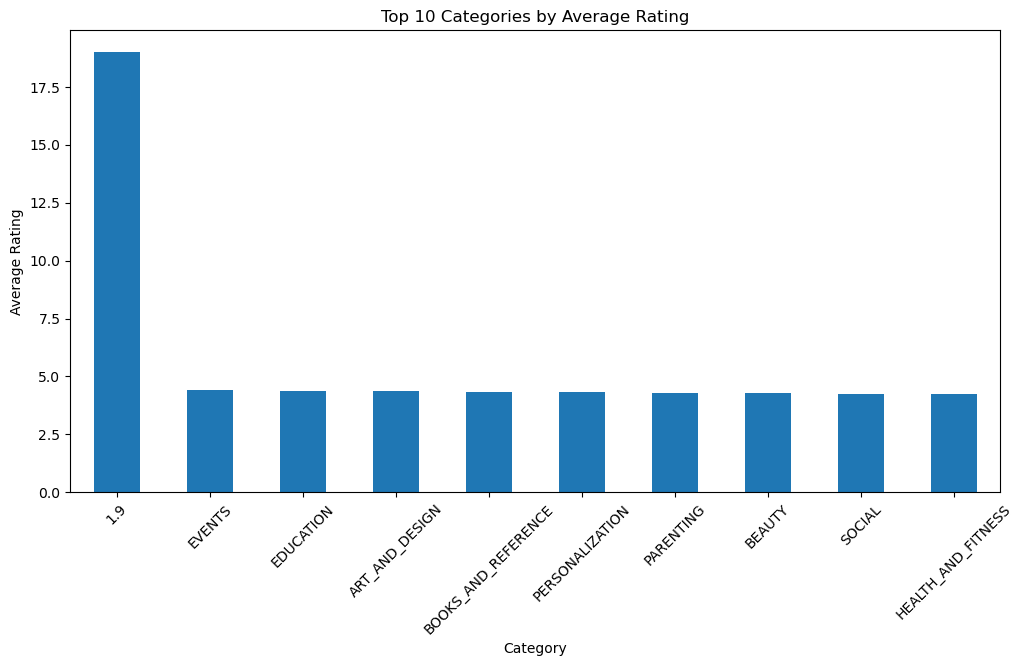

In [46]:
plt.figure(figsize=(12, 6))

top_rated_categories.plot(kind='bar')

plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

plt.show()

### Observation

The rating distribution shows the overall satisfaction level
of users. Comparing average ratings across categories helps
identify categories with relatively higher user ratings.

In [49]:
top_installed = (
    apps[['App', 'Installs']]
    .sort_values(
        by='Installs',
        ascending=False
    )
    .head(10)
)

top_installed

,App,Installs
336,WhatsApp Messenger,1.000000e+09
152,Google Play Books,1.000000e+09
1654,Subway Surfers,1.000000e+09
3117,Maps - Navigate & Explore,1.000000e+09
340,Gmail,1.000000e+09
2545,Instagram,1.000000e+09
2544,Facebook,1.000000e+09
338,Google Chrome: Fast & Secure,1.000000e+09
2554,Google+,1.000000e+09
3665,YouTube,1.000000e+09


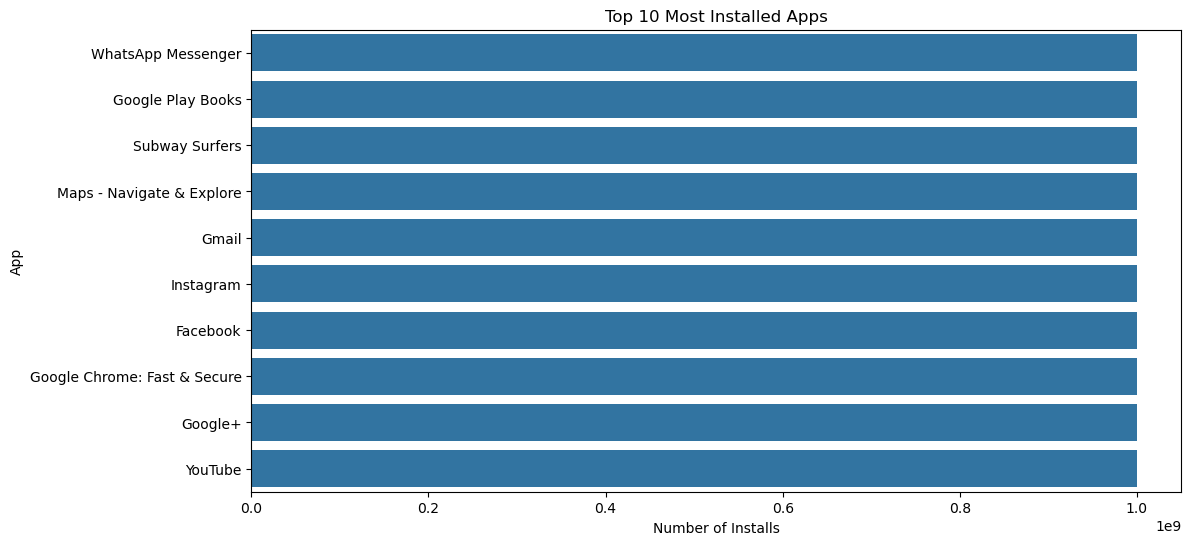

In [50]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_installed,
    x='Installs',
    y='App'
)

plt.title('Top 10 Most Installed Apps')
plt.xlabel('Number of Installs')
plt.ylabel('App')

plt.show()

### Observation

The most installed applications indicate which apps have
the highest user reach in the dataset.

## App Size vs Number of Installs

This section analyzes whether app size has a relationship
with the number of installations.

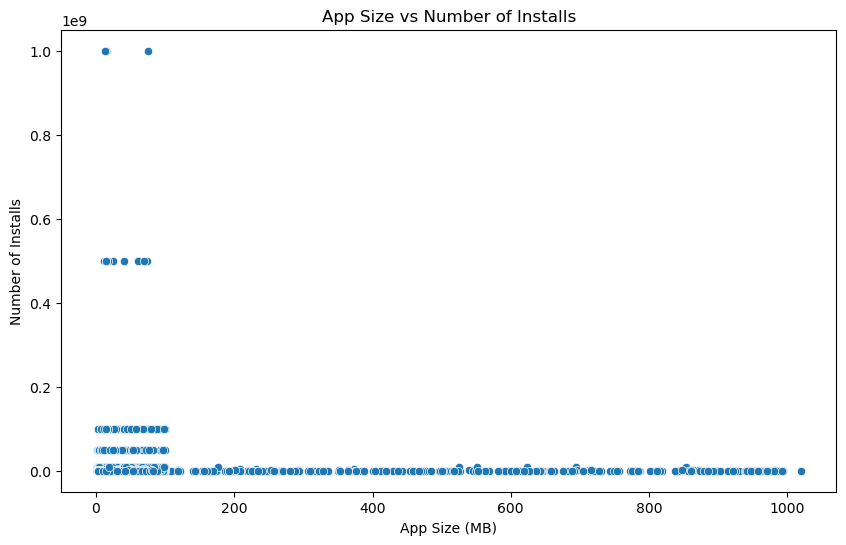

In [52]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=apps,
    x='Size',
    y='Installs'
)

plt.title('App Size vs Number of Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs')

plt.show()

In [53]:
correlation = apps['Size'].corr(apps['Installs'])

print("Correlation between App Size and Installs:", correlation)

Correlation between App Size and Installs: -0.01235641729839621


### Observation

The scatter plot shows the relationship between application
size and number of installs. The correlation value helps
determine whether app size has a strong or weak relationship
with installations.

## Free vs Paid Apps

This section compares the number of free and paid applications
available on the Google Play Store.

In [54]:
app_type_count = apps['Type'].value_counts()

print(app_type_count)

Type
Free    8902
Paid     756
0          1
Name: count, dtype: int64


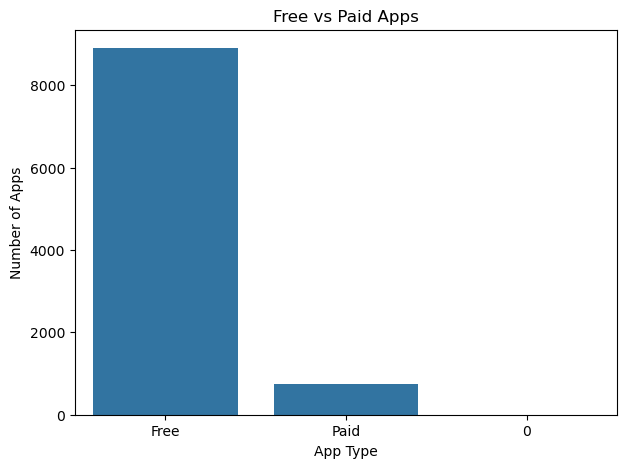

In [55]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=apps,
    x='Type'
)

plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')

plt.show()

In [56]:
type_percentage = (
    apps['Type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(type_percentage)

Type
Free    92.16
Paid     7.83
0        0.01
Name: proportion, dtype: float64


### Observation

The dataset contains a much larger number of free applications
than paid applications. This shows the dominance of the free-app
business model in the dataset.

## Price Analysis

This section analyzes the pricing distribution of paid applications.

In [57]:
paid_apps = apps[apps['Type'] == 'Paid'].copy()

paid_apps[['App', 'Price']].head()

,App,Price
234,TurboScan: scan documents and receipts in PDF,4.99
235,Tiny Scanner Pro: PDF Doc Scan,4.99
427,Puffin Browser Pro,3.99
476,"Moco+ - Chat, Meet People",3.99
477,Calculator,6.99


In [58]:
expensive_apps = (
    paid_apps[['App', 'Price']]
    .sort_values(
        by='Price',
        ascending=False
    )
    .head(10)
)

expensive_apps

,App,Price
4367,I'm Rich - Trump Edition,400.00
5373,I AM RICH PRO PLUS,399.99
4362,💎 I'm rich,399.99
5369,I am Rich,399.99
5364,I am rich (Most expensive app),399.99
5362,I Am Rich Pro,399.99
5359,I am rich(premium),399.99
4197,most expensive app (H),399.99
5356,I Am Rich Premium,399.99
5354,I am Rich Plus,399.99


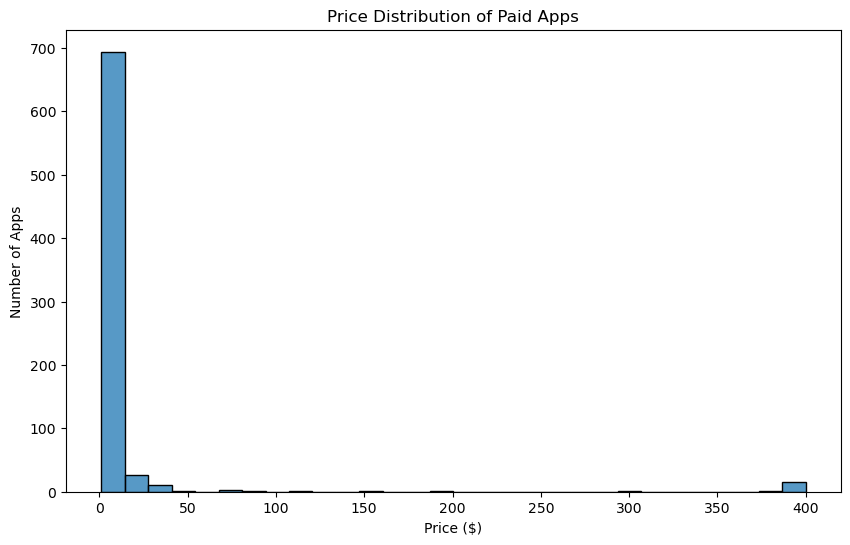

In [59]:
plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps['Price'],
    bins=30
)

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')

plt.show()

### Observation

Most paid applications are concentrated in the lower price
range, while only a small number of applications have relatively
high prices.

In [60]:
paid_apps['Estimated_Revenue'] = (
    paid_apps['Price'] * paid_apps['Installs']
)

In [61]:
revenue_by_category = (
    paid_apps
    .groupby('Category')['Estimated_Revenue']
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category.head(10)

Category
FAMILY             1.136798e+08
LIFESTYLE          5.758394e+07
GAME               4.068864e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.547768e+06
PERSONALIZATION    6.796948e+06
MEDICAL            5.957536e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Estimated_Revenue, dtype: float64

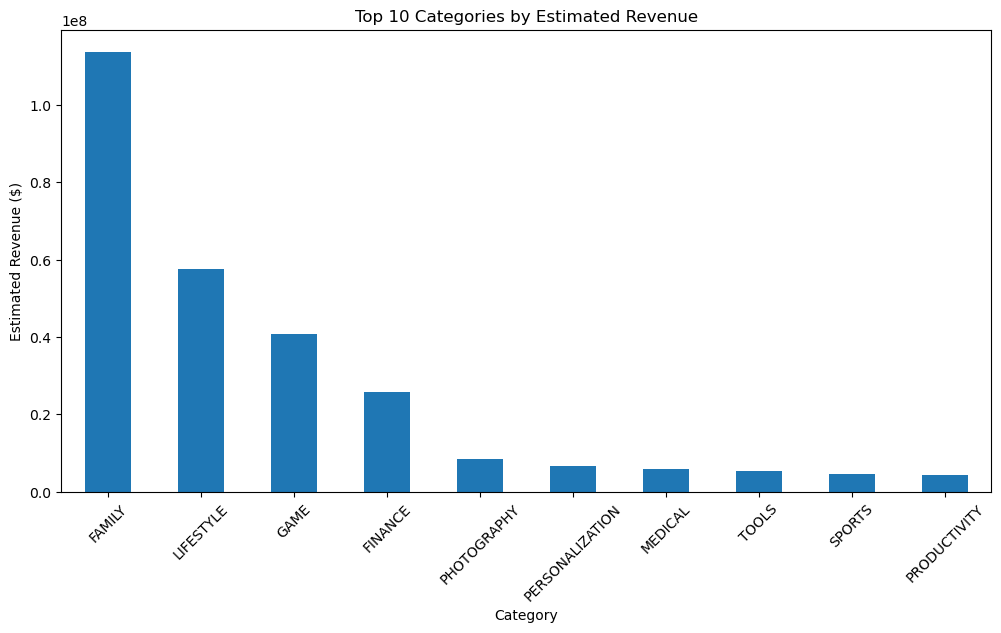

In [62]:
plt.figure(figsize=(12, 6))

revenue_by_category.head(10).plot(kind='bar')

plt.title('Top 10 Categories by Estimated Revenue')
plt.xlabel('Category')
plt.ylabel('Estimated Revenue ($)')
plt.xticks(rotation=45)

plt.show()

### Observation

The estimated revenue analysis identifies categories that
could generate higher revenue based on app price and installs.
This can help developers understand potential commercial
opportunities.

## User Sentiment Analysis

This section analyzes user reviews to understand whether
users have positive, negative, or neutral opinions about apps.

In [63]:
sentiment_count = reviews['Sentiment'].value_counts()

print(sentiment_count)

Sentiment
Positive    19015
Negative     6321
Neutral      4356
Name: count, dtype: int64


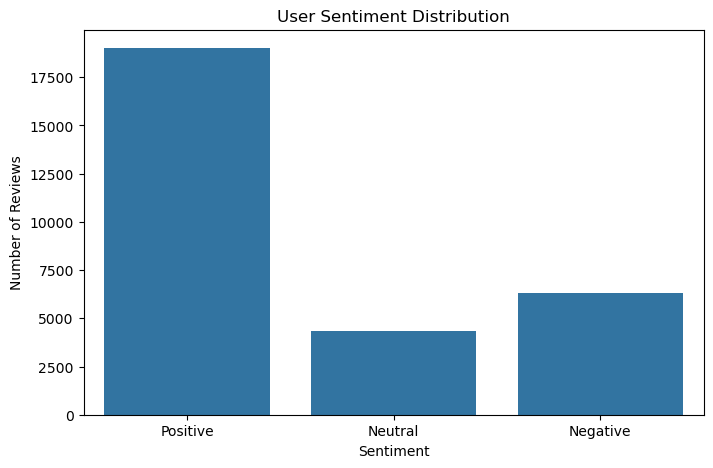

In [64]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews,
    x='Sentiment'
)

plt.title('User Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [65]:
sentiment_percentage = (
    reviews['Sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentage)

Sentiment
Positive    64.04
Negative    21.29
Neutral     14.67
Name: proportion, dtype: float64


### Observation

The sentiment distribution shows the proportion of positive,
negative, and neutral user reviews. Positive reviews indicate
user satisfaction, while negative reviews can highlight areas
that may require improvement.

In [67]:
merged = pd.merge(
    reviews,
    apps[['App', 'Category']],
    on='App',
    how='left'
)

merged.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Category
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,HEALTH_AND_FITNESS
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,HEALTH_AND_FITNESS
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,HEALTH_AND_FITNESS
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,HEALTH_AND_FITNESS
4,10 Best Foods for You,Best way,Positive,1.00,0.300000,HEALTH_AND_FITNESS


In [68]:
merged['Category'].isnull().sum()

np.int64(1442)

In [69]:
sentiment_category = pd.crosstab(
    merged['Category'],
    merged['Sentiment']
)

sentiment_category.head()

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,54,60,240
AUTO_AND_VEHICLES,17,36,230
BEAUTY,60,81,176
BOOKS_AND_REFERENCE,84,106,427
BUSINESS,115,163,379


In [70]:
positive_reviews = (
    merged[merged['Sentiment'] == 'Positive']
    .groupby('Category')
    .size()
    .sort_values(ascending=False)
)

positive_reviews.head(10)

Category
GAME                  2567
HEALTH_AND_FITNESS    1262
FAMILY                1117
TOOLS                  842
FINANCE                841
TRAVEL_AND_LOCAL       831
MEDICAL                790
SPORTS                 770
PRODUCTIVITY           758
DATING                 669
dtype: int64

In [71]:
negative_reviews = (
    merged[merged['Sentiment'] == 'Negative']
    .groupby('Category')
    .size()
    .sort_values(ascending=False)
)

negative_reviews.head(10)

Category
GAME                1541
FAMILY               498
FINANCE              300
SPORTS               284
TRAVEL_AND_LOCAL     267
TOOLS                239
DATING               228
ENTERTAINMENT        213
PRODUCTIVITY         208
SOCIAL               190
dtype: int64

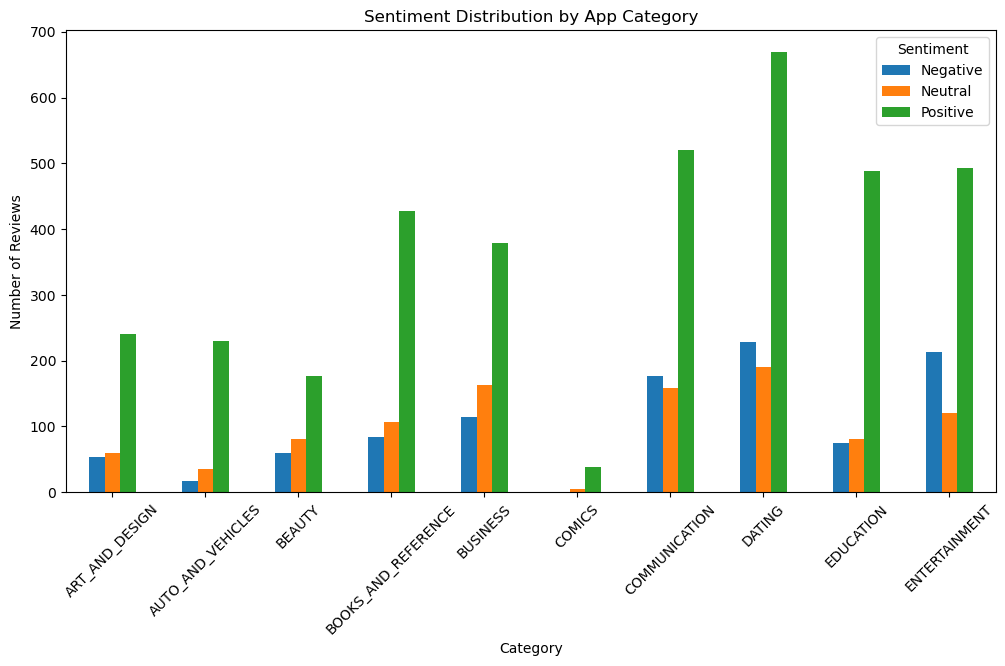

In [72]:
sentiment_category.head(10).plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Sentiment Distribution by App Category')
plt.xlabel('Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)

plt.show()

### Observation

Sentiment analysis helps identify categories receiving
more positive or negative user feedback. Categories with
more negative feedback can indicate areas where developers
may need to improve app quality or user experience.

In [73]:
most_positive_category = positive_reviews.idxmax()
most_positive_count = positive_reviews.max()

print("Most positive category:", most_positive_category)
print("Positive reviews:", most_positive_count)

Most positive category: GAME
Positive reviews: 2567


In [74]:
most_negative_category = negative_reviews.idxmax()
most_negative_count = negative_reviews.max()

print("Most negative category:", most_negative_category)
print("Negative reviews:", most_negative_count)

Most negative category: GAME
Negative reviews: 1541


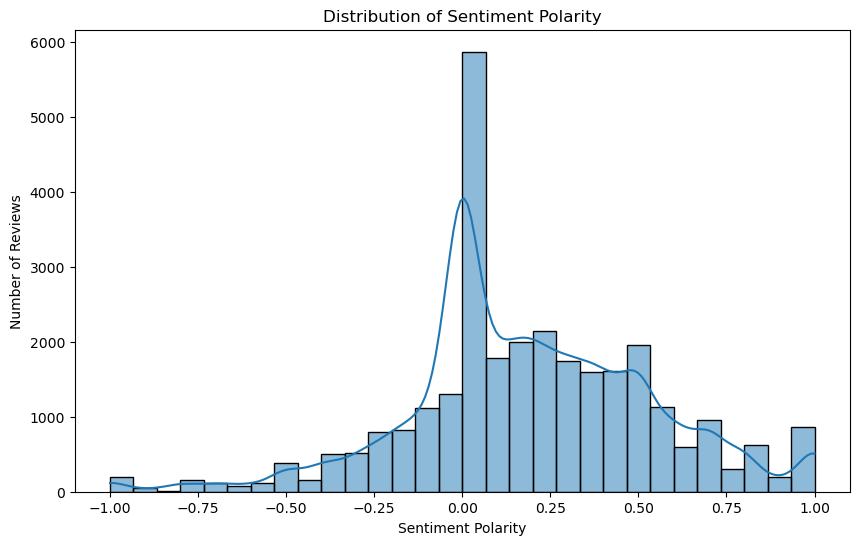

In [75]:
plt.figure(figsize=(10, 6))

sns.histplot(
    reviews['Sentiment_Polarity'].dropna(),
    bins=30,
    kde=True
)

plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Number of Reviews')

plt.show()

In [76]:
reviews['Sentiment_Polarity'].describe()

count    29692.000000
mean         0.188868
std          0.355694
min         -1.000000
25%          0.000000
50%          0.157143
75%          0.422917
max          1.000000
Name: Sentiment_Polarity, dtype: float64

### Observation

Sentiment polarity represents the strength and direction
of sentiment in user reviews. Positive values indicate
more positive sentiment, while negative values indicate
more negative sentiment.

In [77]:
import plotly.express as px

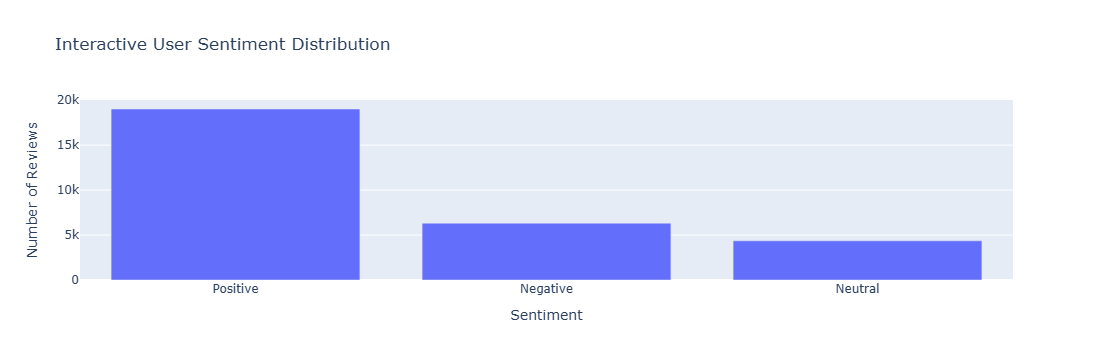

In [78]:
fig = px.bar(
    sentiment_count,
    x=sentiment_count.index,
    y=sentiment_count.values,
    title='Interactive User Sentiment Distribution',
    labels={
        'x': 'Sentiment',
        'y': 'Number of Reviews'
    }
)

fig.show()

## Business Insights

### Insight 1: Category Competition
Categories with a large number of applications are highly
competitive. Developers should study existing apps carefully
before entering these categories.

### Insight 2: User Satisfaction
App ratings and sentiment analysis help identify categories
where users are more satisfied. Developers should focus on
features that improve user experience and ratings.

### Insight 3: Pricing and Revenue
The estimated revenue analysis helps identify categories
with better commercial potential. Developers can use pricing,
install counts, and user feedback when deciding the pricing
strategy for a new application.

## Conclusion

The Google Play Store dataset was analyzed to understand
application categories, ratings, installations, app size,
pricing, estimated revenue, and user sentiment.

Data cleaning was performed to handle missing values,
duplicates, and inconsistent data types. Exploratory data
analysis helped identify important patterns in the app market.

Sentiment analysis provided additional information about
user opinions and helped identify positive and negative
feedback across different categories.

Overall, the analysis can help developers understand market
competition, user preferences, and potential business
opportunities before launching a new application.

In [79]:
apps.to_csv(
    "cleaned_googleplaystore.csv",
    index=False
)

In [80]:
reviews.to_csv(
    "cleaned_googleplaystore_user_reviews.csv",
    index=False
)

print("Cleaned datasets saved successfully!")

Cleaned datasets saved successfully!


In [81]:
print("Final Apps Dataset Shape:", apps.shape)
print("Final Reviews Dataset Shape:", reviews.shape)

Final Apps Dataset Shape: (9660, 13)
Final Reviews Dataset Shape: (29692, 5)


In [82]:
print("Apps Missing Values:")
print(apps.isnull().sum())

Apps Missing Values:
App               0
Category          0
Rating            0
Reviews           1
Size              0
Installs          1
Type              1
Price             1
Content Rating    1
Genres            0
Last Updated      0
Current Ver       8
Android Ver       3
dtype: int64


In [83]:
print("Reviews Missing Values:")
print(reviews.isnull().sum())

Reviews Missing Values:
App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64
